# StreamSafe: разведочный анализ данных

Ноутбук исследует исходные файлы, схемы, метки безопасности, категории вреда, длины текстов, дубликаты и префиксную разметку, необходимые для будущего бенчмарка потоковых защитных механизмов. На этом этапе исходные записи не нормализуются и не публикуются. Полные чувствительные тексты в выводах не отображаются.

## 1. Настройки анализа

Версионируемая конфигурация задаёт источник данных и случайное начальное состояние. Точные технические версии сохраняются внутри конфигурации, но не выводятся в отчёте.

In [1]:
from __future__ import annotations

import platform
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import disable_progress_bars
from IPython.display import Markdown, display

from streamguard_bench.data.inspect_schema import (
    align_streamsafe_prefixes,
    dataset_overview,
    distribution_for_role,
    duplicate_summary,
    length_statistics,
    missing_values_summary,
    prefix_transition_summary,
    schema_summary,
    streamsafe_trace_summary,
)
from streamguard_bench.data.load_streamsafe import load_streamsafe, load_yaml_config
from streamguard_bench.data.validate_raw import validate_tables

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'data_streamsafe.yaml'
config = load_yaml_config(CONFIG_PATH)
sns.set_theme(style='whitegrid')
disable_progress_bars()
TABLE_NAMES_RU = {
    'full_response_mix2_1_8k_train': 'Полные ответы — обучение',
    'full_response_mix2_1_8k_val': 'Полные ответы — валидация',
    'partial_response_mix2_1_53k_train': 'Префиксы — обучение',
    'partial_response_mix2_1_53k_val': 'Префиксы — валидация',
    'test': 'Полные ответы — отложенный тест',
}
LABEL_NAMES_RU = {
    'safe': 'Безопасный (safe)',
    'unsafe': 'Опасный (unsafe)',
    'uncertain': 'Неопределённый (uncertain)',
}
CATEGORY_NAMES_RU = {
    '<missing>': 'Нет указанного нарушения',
    'Non-violent Illegal Acts': 'Ненасильственные незаконные действия',
    'Unethical Acts': 'Неэтичные действия',
    'Violent': 'Насилие',
    'Politically Sensitive Topics': 'Политически чувствительные темы',
    'Personally Identifiable Information': 'Персональные идентифицирующие данные',
    'Copyright Violation': 'Нарушение авторских прав',
    'Sexual Content or Sexual Acts': 'Сексуальный контент или действия',
    'Suicide & Self-Harm': 'Самоубийство и самоповреждение',
}
print({
    'версия_python': platform.python_version(),
    'репозиторий': config['dataset']['repository'],
    'случайное_начальное_состояние': config['analysis']['random_seed'],
})

{'версия_python': '3.11.14', 'репозиторий': 'Solitude0630/StreamSafe', 'случайное_начальное_состояние': 42}


In [2]:
bundle = load_streamsafe(
    repository=config['dataset']['repository'],
    revision=config['dataset']['revision'],
    cache_dir=PROJECT_ROOT / config['dataset']['cache_dir'],
    allow_remote_code=config['loading']['allow_remote_code'],
)
tables = bundle.tables
total_rows = sum(len(frame) for frame in tables.values())
print(f'Загружено независимых таблиц: {len(tables)}; всего строк: {total_rows:,}')
print(f'Режим загрузчика: {bundle.loader_mode.partition(":")[0]}')

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Загружено независимых таблиц: 5; всего строк: 61,811
Режим загрузчика: snapshot_fallback


## 2. Как устроен StreamSafe

Логически набор состоит из **трёх конфигураций**, но физически содержит **пять таблиц**, потому что первые две конфигурации разделены на обучающую и валидационную части:

1. **`full_response` — полные ответы.** Обучающая и валидационная таблицы содержат законченные пары «запрос пользователя — полный ответ модели». Они подходят для обычной модерации, когда решение принимается после завершения генерации.
2. **`partial_response` — частичные ответы, или префиксы.** Это тоже обучающая и валидационная таблицы. Префикс не имеет фиксированного размера: это не первые 100 слов и не первые 50 токенов. Авторы обрезают полный ответ на промежуточных **границах предложений**. Для каждого накопленного префикса задаётся собственная метка, поэтому один ответ может сначала быть безопасным, а после добавления очередного предложения стать опасным.
3. **`test` — отложенная тестовая таблица.** Она содержит 1 200 **полных**, а не частичных ответов. В отличие от обучающих данных, здесь используется только бинарная метка `safe/unsafe`, а ответы включают технические маркеры `<think>...</think><output>...</output>`.

Условный искусственный пример, не взятый из StreamSafe:

- **Полный ответ:** «Сначала обсудим общие риски. ... `[опасная инструкция скрыта]` ... Поэтому выполнять такие действия нельзя» → итоговая метка `unsafe`.
- **Частичный ответ, префикс 1:** «Сначала обсудим общие риски.» → `safe`; **префикс 2:** «Сначала обсудим общие риски. ... `[начало опасной инструкции скрыто]`» → `unsafe`.

Таким образом, строки `partial_response` — это отдельные состояния растущего ответа, а не независимые завершённые ответы.

In [3]:
tables_dir = PROJECT_ROOT / config['reports']['tables_dir']
figures_dir = PROJECT_ROOT / config['reports']['figures_dir']
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

overview = dataset_overview(tables)
schema = schema_summary(tables)
overview.to_csv(tables_dir / 'dataset_overview.csv', index=False)
schema.to_csv(tables_dir / 'raw_schema_summary.csv', index=False)
overview_display = overview[['table', 'rows', 'columns']].copy()
overview_display['table'] = overview_display['table'].map(TABLE_NAMES_RU)
overview_display = overview_display.rename(columns={
    'table': 'Таблица', 'rows': 'Строк', 'columns': 'Столбцов'
})
overview_display

,Таблица,Строк,Столбцов
0,Полные ответы — обучение,6958,6
1,Полные ответы — валидация,772,6
2,Префиксы — обучение,49286,6
3,Префиксы — валидация,3595,6
4,Полные ответы — отложенный тест,1200,4


## 3. Качество данных: пропуски и дубликаты

Под **точным дубликатом** здесь понимается повтор строки с той же парой текстовых полей `query` и `response`. Совпадение только запроса не считается точным дубликатом: в префиксной части один запрос закономерно повторяется для нескольких состояний ответа.

In [4]:
missing = missing_values_summary(tables)
duplicates = duplicate_summary(tables)
validation = validate_tables(tables).to_frame()
missing.to_csv(tables_dir / 'missing_values.csv', index=False)
duplicates.to_csv(tables_dir / 'duplicate_summary.csv', index=False)
validation.to_csv(tables_dir / 'raw_validation.csv', index=False)
duplicate_counts = (
    validation[validation['code'] == 'duplicate_rows']
    .set_index('table')['count']
)
duplicate_check = overview[['table', 'rows']].copy()
duplicate_check['duplicate_rows'] = (
    duplicate_check['table'].map(duplicate_counts).fillna(0).astype(int)
)
duplicate_check['result'] = duplicate_check['duplicate_rows'].map(
    lambda count: 'Есть точные дубликаты — требуется проверка'
    if count else 'Точные дубликаты не найдены'
)
duplicate_check['table'] = duplicate_check['table'].map(TABLE_NAMES_RU)
duplicate_check = duplicate_check.rename(columns={
    'table': 'Таблица',
    'rows': 'Всего строк',
    'duplicate_rows': 'Строк в группах точных дубликатов',
    'result': 'Итог',
})
duplicate_check

,Таблица,Всего строк,Строк в группах точных дубликатов,Итог
0,Полные ответы — обучение,6958,36,Есть точные дубликаты — требуется проверка
1,Полные ответы — валидация,772,0,Точные дубликаты не найдены
2,Префиксы — обучение,49286,158,Есть точные дубликаты — требуется проверка
3,Префиксы — валидация,3595,10,Есть точные дубликаты — требуется проверка
4,Полные ответы — отложенный тест,1200,2,Есть точные дубликаты — требуется проверка


Анализ только фиксирует дубликаты: **строки не удалялись и не изменялись**. Это сознательное решение первого этапа, поскольку удаление должно выполняться после нормализации и проверки пересечений между частями набора.

## 4. Метки безопасности

В обучающих и валидационных таблицах используется три метки:

- **`safe`** — наблюдаемый ответ или префикс безопасен;
- **`unsafe`** — ответ уже содержит или начал раскрывать опасное содержание;
- **`uncertain`** — пограничный случай, который нельзя уверенно отнести к безопасному или опасному.

Тестовая таблица использует только две метки: `safe` и `unsafe`. Числа ниже относятся к строкам, а не к уникальным полным ответам: один ответ может давать несколько префиксных строк.

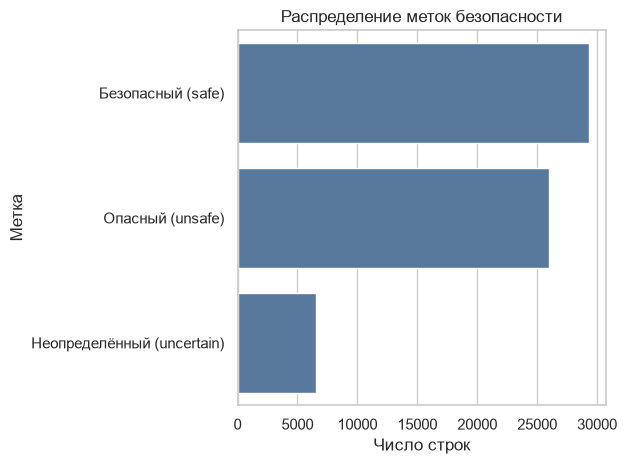

,Таблица,Поле,Метка,Строк
3,Полные ответы — обучение,answer,Безопасный (safe),3903
4,Полные ответы — обучение,answer,Опасный (unsafe),2965
5,Полные ответы — обучение,answer,Неопределённый (uncertain),90
9,Полные ответы — валидация,answer,Безопасный (safe),424
10,Полные ответы — валидация,answer,Опасный (unsafe),334
11,Полные ответы — валидация,answer,Неопределённый (uncertain),14
15,Префиксы — обучение,answer,Безопасный (safe),22570
16,Префиксы — обучение,answer,Опасный (unsafe),20620
17,Префиксы — обучение,answer,Неопределённый (uncertain),6096
21,Префиксы — валидация,answer,Безопасный (safe),1705


In [5]:
all_label_fields = distribution_for_role(tables, 'label')
labels = all_label_fields[all_label_fields['column'].isin(['answer', 'label'])].copy()
labels.to_csv(tables_dir / 'label_distribution.csv', index=False)
if not labels.empty:
    plot_data = labels.groupby('value', as_index=False)['count'].sum().nlargest(20, 'count')
    plot_data['label_ru'] = plot_data['value'].map(LABEL_NAMES_RU)
    ax = sns.barplot(data=plot_data, x='count', y='label_ru', color='#4C78A8')
    ax.set(title='Распределение меток безопасности', xlabel='Число строк', ylabel='Метка')
    plt.tight_layout()
    plt.savefig(figures_dir / 'label_distribution.png', dpi=160, bbox_inches='tight')
    plt.show()
label_display = labels.copy()
label_display['table'] = label_display['table'].map(TABLE_NAMES_RU)
label_display['value'] = label_display['value'].map(LABEL_NAMES_RU)
label_display.rename(columns={
    'table': 'Таблица', 'column': 'Поле', 'value': 'Метка', 'count': 'Строк'
}).head(30)

## 5. Категории вреда

Поле `violated_categories` многометочное: одна строка может нарушать несколько категорий одновременно. В StreamSafe используются восемь категорий:

- **Non-violent Illegal Acts** — ненасильственные незаконные действия;
- **Unethical Acts** — неэтичные действия, не обязательно выделенные как отдельное преступление;
- **Violent** — насилие и причинение физического вреда;
- **Politically Sensitive Topics** — политически чувствительные темы;
- **Personally Identifiable Information** — раскрытие или использование данных, позволяющих идентифицировать человека;
- **Copyright Violation** — нарушение авторских прав;
- **Sexual Content or Sexual Acts** — сексуальный контент или действия;
- **Suicide & Self-Harm** — самоубийство и самоповреждение.

Значение `<missing>` на графике **не является девятой категорией и обычно не означает ошибку разметки**. Оно появляется, когда список `violated_categories` пуст: чаще всего для безопасной строки просто нет нарушенной категории. Ниже оно отображается как «Нет указанного нарушения». Точные границы восьми категорий авторы набора подробно не формализуют, поэтому их названия пока сохраняются без переопределения.

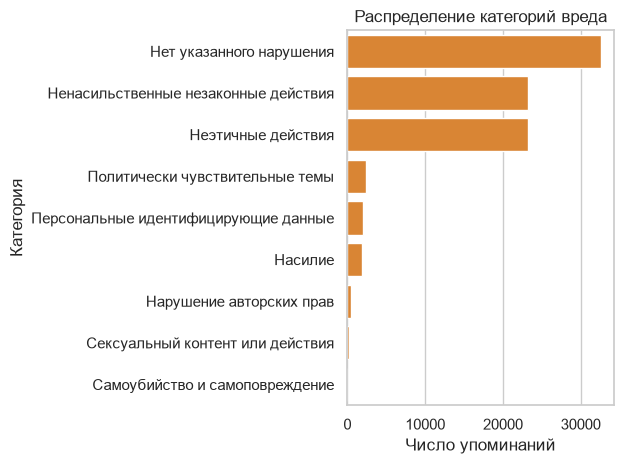

,Таблица,Поле,Категория,Упоминаний
0,Полные ответы — обучение,violated_categories,Нет указанного нарушения,3902
1,Полные ответы — обучение,violated_categories,Неэтичные действия,2654
2,Полные ответы — обучение,violated_categories,Ненасильственные незаконные действия,2580
3,Полные ответы — обучение,violated_categories,Политически чувствительные темы,262
4,Полные ответы — обучение,violated_categories,Персональные идентифицирующие данные,256
5,Полные ответы — обучение,violated_categories,Насилие,216
6,Полные ответы — обучение,violated_categories,Нарушение авторских прав,62
7,Полные ответы — обучение,violated_categories,Сексуальный контент или действия,28
8,Полные ответы — обучение,violated_categories,Самоубийство и самоповреждение,1
9,Полные ответы — валидация,violated_categories,Нет указанного нарушения,425


In [6]:
categories = distribution_for_role(tables, 'category')
categories.to_csv(tables_dir / 'harm_category_distribution.csv', index=False)
if not categories.empty:
    plot_data = categories.groupby('value', as_index=False)['count'].sum().nlargest(20, 'count')
    plot_data['category_ru'] = plot_data['value'].map(CATEGORY_NAMES_RU)
    ax = sns.barplot(data=plot_data, x='count', y='category_ru', color='#F58518')
    ax.set(title='Распределение категорий вреда', xlabel='Число упоминаний', ylabel='Категория')
    plt.tight_layout()
    plt.savefig(figures_dir / 'harm_category_distribution.png', dpi=160, bbox_inches='tight')
    plt.show()
category_display = categories.copy()
category_display['table'] = category_display['table'].map(TABLE_NAMES_RU)
category_display['value'] = category_display['value'].map(CATEGORY_NAMES_RU)
category_display.rename(columns={
    'table': 'Таблица', 'column': 'Поле', 'value': 'Категория', 'count': 'Упоминаний'
}).head(30)

## 6. Длины запросов и ответов

Для запросов и ответов вычисляются длины в символах, байтах в кодировке UTF-8, словах и приблизительных предложениях. Исходные тексты при этом не сохраняются в отчётах. Длины в токенах будут добавлены после подключения токенизатора Qwen3Guard. График сравнивает медианную длину ответа в каждой исходной таблице и наглядно показывает, насколько префиксы короче полных ответов.

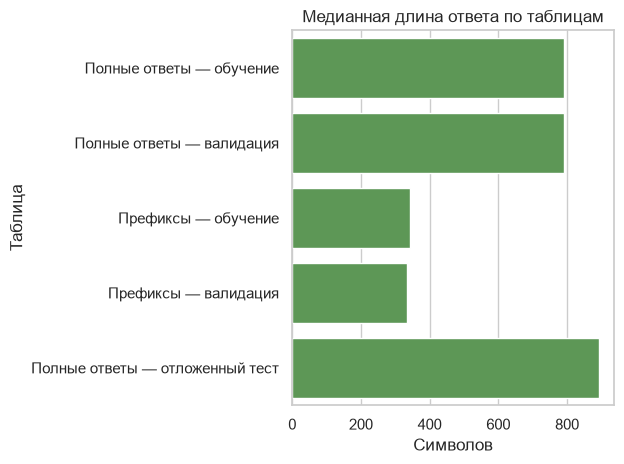

,Таблица,column,role,Единица,Строк,Среднее,std,Минимум,p25,Медиана,p75,p95,Максимум
4,Полные ответы — обучение,response,response,символы,6958,756.849,286.394,4,585.0,792.0,936.75,1144.30,6337
5,Полные ответы — обучение,response,response,байты UTF-8,6958,757.749,286.328,4,587.0,793.0,937.00,1144.30,6339
6,Полные ответы — обучение,response,response,слова,6958,119.558,42.113,1,95.0,125.0,146.00,177.00,758
7,Полные ответы — обучение,response,response,предложения (приблизительно),6958,6.949,3.038,1,5.0,7.0,8.00,11.00,34
12,Полные ответы — валидация,response,response,символы,772,752.543,270.937,36,593.5,791.5,918.50,1141.90,2114
13,Полные ответы — валидация,response,response,байты UTF-8,772,753.487,270.880,36,593.5,791.5,920.00,1141.90,2122
14,Полные ответы — валидация,response,response,слова,772,119.407,40.595,8,97.0,125.0,144.00,178.00,372
15,Полные ответы — валидация,response,response,предложения (приблизительно),772,6.908,2.766,1,5.0,7.0,8.00,11.00,24
20,Префиксы — обучение,response,response,символы,49286,387.921,257.273,2,180.0,342.0,548.00,868.00,6337
21,Префиксы — обучение,response,response,байты UTF-8,49286,388.310,257.382,2,181.0,343.0,548.00,868.75,6339


In [7]:
lengths = length_statistics(tables)
lengths.to_csv(tables_dir / 'length_statistics.csv', index=False)
response_lengths = lengths[(lengths['role'] == 'response') & (lengths['measure'] == 'characters')]
if not response_lengths.empty:
    response_lengths_plot = response_lengths.copy()
    response_lengths_plot['table'] = response_lengths_plot['table'].map(TABLE_NAMES_RU)
    ax = sns.barplot(data=response_lengths_plot, x='median', y='table', color='#54A24B')
    ax.set(title='Медианная длина ответа по таблицам', xlabel='Символов', ylabel='Таблица')
    plt.tight_layout()
    plt.savefig(figures_dir / 'response_length_by_table.png', dpi=160, bbox_inches='tight')
    plt.show()
lengths_display = lengths[lengths['role'] == 'response'].copy()
lengths_display['table'] = lengths_display['table'].map(TABLE_NAMES_RU)
lengths_display['measure'] = lengths_display['measure'].map({
    'characters': 'символы', 'bytes_utf8': 'байты UTF-8',
    'words': 'слова', 'sentences_approx': 'предложения (приблизительно)',
})
lengths_display.rename(columns={
    'table': 'Таблица', 'measure': 'Единица', 'count': 'Строк',
    'mean': 'Среднее', 'median': 'Медиана', 'min': 'Минимум', 'max': 'Максимум',
})

## 7. Структура префиксов и переходы меток

StreamSafe не предоставляет явный идентификатор, связывающий каждый префикс с его полным ответом. Поэтому здесь префикс связывается с полным ответом только тогда, когда одновременно выполняются три условия: совпадает запрос, совпадает режим ответа и ровно один полный ответ начинается с данного префикса. Неоднозначные и несопоставленные строки не используются при расчёте переходов.

Используемые показатели:

- **число префиксов на трассу** — сколько промежуточных состояний ответа удалось однозначно связать с одним полным ответом; это не число токенов и не длина текста;
- **число переходов метки** — сколько раз метка меняется при росте ответа, например `safe → uncertain → unsafe` даёт два перехода;
- **позиция первого опасного префикса** — отношение длины первого префикса с меткой `unsafe` к длине полного ответа в символах. Значение 0,75 означает, что опасность впервые наблюдается примерно после 75% полного текста. Это граница предложения, а не точная позиция первого опасного символа.

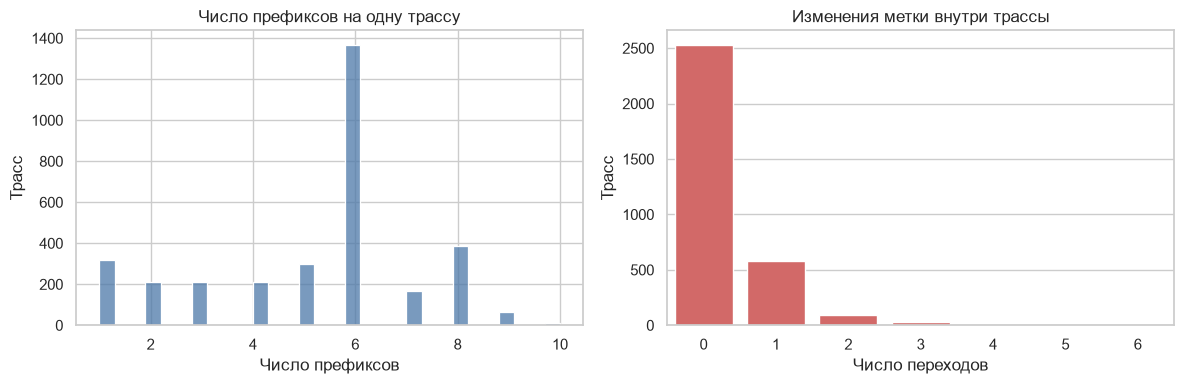

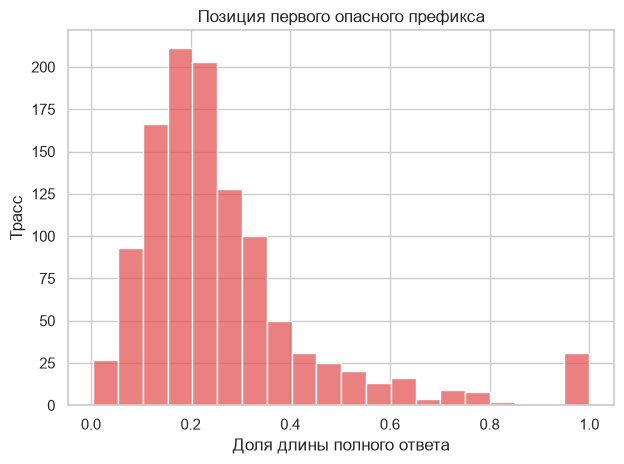

,Часть,Результат сопоставления,Префиксов,"Доля, %"
0,Обучение,Несколько возможных полных ответов,724,1.468977
1,Обучение,Однозначно сопоставлен,15280,31.002719
2,Обучение,Полный ответ не найден,33282,67.528304
3,Валидация,Несколько возможных полных ответов,12,0.333797
4,Валидация,Однозначно сопоставлен,1588,44.172462
5,Валидация,Полный ответ не найден,1995,55.493741


In [8]:
generic_transitions = prefix_transition_summary(tables)
alignment_parts = []
trace_parts = []
for split in ('train', 'val'):
    full_name = next(name for name in tables if name.startswith('full_response') and name.endswith(split))
    partial_name = next(name for name in tables if name.startswith('partial_response') and name.endswith(split))
    aligned = align_streamsafe_prefixes(tables[full_name], tables[partial_name])
    aligned['split'] = split
    traces = streamsafe_trace_summary(aligned)
    traces['split'] = split
    alignment_parts.append(aligned)
    trace_parts.append(traces)
alignment = pd.concat(alignment_parts, ignore_index=True)
transitions = pd.concat(trace_parts, ignore_index=True)
alignment_quality = alignment.groupby(['split', 'status'], as_index=False).size()
alignment_quality['percent'] = alignment_quality.groupby('split')['size'].transform(lambda s: 100 * s / s.sum())
alignment_quality.to_csv(tables_dir / 'prefix_alignment_quality.csv', index=False)
transitions.to_csv(tables_dir / 'prefix_transition_summary.csv', index=False)
if not transitions.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(transitions['prefix_count'], bins=30, ax=axes[0], color='#4C78A8')
    axes[0].set(title='Число префиксов на одну трассу', xlabel='Число префиксов', ylabel='Трасс')
    sns.countplot(data=transitions, x='label_transitions', ax=axes[1], color='#E45756')
    axes[1].set(title='Изменения метки внутри трассы', xlabel='Число переходов', ylabel='Трасс')
    plt.tight_layout()
    plt.savefig(figures_dir / 'prefix_structure.png', dpi=160, bbox_inches='tight')
    plt.show()
    unsafe_onsets = transitions['first_unsafe_fraction'].dropna()
    if not unsafe_onsets.empty:
        ax = sns.histplot(unsafe_onsets, bins=20, color='#E45756')
        ax.set(title='Позиция первого опасного префикса', xlabel='Доля длины полного ответа', ylabel='Трасс')
        plt.tight_layout()
        plt.savefig(figures_dir / 'first_unsafe_prefix_position.png', dpi=160, bbox_inches='tight')
        plt.show()
alignment_quality_display = alignment_quality.copy()
alignment_quality_display['split'] = alignment_quality_display['split'].map({
    'train': 'Обучение', 'val': 'Валидация'
})
alignment_quality_display['status'] = alignment_quality_display['status'].map({
    'unique': 'Однозначно сопоставлен',
    'ambiguous': 'Несколько возможных полных ответов',
    'unmatched': 'Полный ответ не найден',
})
alignment_quality_display.rename(columns={
    'split': 'Часть', 'status': 'Результат сопоставления',
    'size': 'Префиксов', 'percent': 'Доля, %',
})

### Как читать графики раздела 7

Левая часть графика `prefix_structure.png` показывает, сколько наблюдаемых префиксов приходится на один восстановленный ответ. Правая часть показывает стабильность метки: ноль означает, что она не менялась, а значения больше нуля — что оценка безопасности менялась по мере появления новых предложений. График `first_unsafe_prefix_position.png` показывает, насколько поздно появляется первая метка `unsafe`: чем ближе значение к единице, тем больше текста уже сгенерировано к моменту обнаружения.

## 8. Ответы на вопросы о первой выборке

Точные пересечения между обучающей, валидационной и тестовой частями, а также окончательная сбалансированная выборка требуют следующего этапа нормализации: у исходных файлов различаются схемы, а явного общего идентификатора трассы нет.

In [9]:
safety_counts = labels.groupby('value')['count'].sum().to_dict()
unique_alignment_rate = 100 * (alignment['status'] == 'unique').mean()
subset_feasible = (
    len(transitions) >= 500
    and safety_counts.get('safe', 0) >= 250
    and safety_counts.get('unsafe', 0) >= 250
)
candidate_summary = pd.DataFrame([
    {
        'metric': 'safe_rows',
        'value': int(safety_counts.get('safe', 0)),
        'interpretation': 'Строки с меткой safe во всех частях',
    },
    {
        'metric': 'unsafe_rows',
        'value': int(safety_counts.get('unsafe', 0)),
        'interpretation': 'Строки с меткой unsafe во всех частях',
    },
    {
        'metric': 'uncertain_rows',
        'value': int(safety_counts.get('uncertain', 0)),
        'interpretation': 'Строки с меткой uncertain в train/validation',
    },
    {
        'metric': 'uniquely_aligned_traces',
        'value': len(transitions),
        'interpretation': 'Трассы, восстановленные без неоднозначности',
    },
    {
        'metric': 'unique_prefix_rate_percent',
        'value': round(float(unique_alignment_rate), 2),
        'interpretation': 'Доля однозначно сопоставленных префиксов, %',
    },
])
candidate_summary.to_csv(tables_dir / 'candidate_subset_assessment.csv', index=False)
display(Markdown(f'''
- Метки обнаружены во всех ожидаемых полях: **{safety_counts.get('safe', 0):,}** строк `safe`, **{safety_counts.get('unsafe', 0):,}** строк `unsafe` и **{safety_counts.get('uncertain', 0):,}** строк `uncertain`.
- Все восемь категорий вреда присутствуют, но распределены неравномерно.
- Без неоднозначности восстановлено **{len(transitions):,}** трасс; однозначно сопоставлено **{unique_alignment_rate:.2f}%** префиксных строк.
- Сбалансированная первая выборка из 500 трасс **{'доступна по текущим числам' if subset_feasible else 'пока не гарантирована'}**, а итоговые 500 трасс уже опубликованы в `Vovarus12go/streamsafe-500-boundaries`.
'''))


- Метки обнаружены во всех ожидаемых полях: **29,285** строк `safe`, **25,982** строк `unsafe` и **6,544** строк `uncertain`.
- Все восемь категорий вреда присутствуют, но распределены неравномерно.
- Без неоднозначности восстановлено **3,249** трасс; однозначно сопоставлено **31.90%** префиксных строк.
- Сбалансированная первая выборка из 500 трасс **доступна по текущим числам**, а итоговые 500 трасс уже опубликованы в `Vovarus12go/streamsafe-500-boundaries`.


## 9. Ограничения и итог анализа

1. Исходные схемы намеренно не объединяются автоматически.
2. Роли столбцов определяются эвристически и сверяются с документацией набора.
3. StreamSafe не содержит общего идентификатора полного ответа и его префиксов, поэтому строгая нормализация сохраняет только однозначные связи.
4. Наблюдаемая позиция появления вреда соответствует границе размеченного предложения, а не точной границе вредоносного фрагмента.
5. Категории распределены неравномерно, а текущий выпуск состоит из английских ответов.
6. Итоговые 500 трасс опубликованы в [Vovarus12go/streamsafe-500-boundaries](https://huggingface.co/datasets/Vovarus12go/streamsafe-500-boundaries); следующий этап может сразу использовать их для запуска защитных моделей.